## Credit card fraud detection using imbalanced dataset.
### Dataset: Kaggle creditcard.csv

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.preprocessing import StandardScaler 
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve,auc,confusion_matrix,classification_report
import pickle

In [27]:
df = pd.read_csv("creditcard.csv")
df 

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


### EDA

Class distribution

Fraud vs Legit count

In [3]:
df.isnull().sum().any()

False

In [4]:
df.dtypes.value_counts()

float64    30
int64       1
Name: count, dtype: int64

In [5]:
df.shape

(284807, 31)

In [6]:
df = df.drop("Time",axis = 1)

In [12]:
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [7]:
X = df.drop("Class", axis = 1)
y = df["Class"]

### Data Preprocessing

- Train-test split
- Scaling (Amount column)


In [8]:
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [9]:
scaler = StandardScaler()
X_train["Amount"] = scaler.fit_transform(X_train[["Amount"]])
X_test["Amount"] = scaler.transform(X_test[["Amount"]])

In [10]:
X_train.shape

(227845, 29)

In [11]:
iso = IsolationForest(contamination= 0.0017, random_state = 42)
iso.fit(X_train)

iso_preds = iso.predict(X_test)
iso_preds = [1 if x == -1 else 0 for x in iso_preds ]

In [12]:
lof = LocalOutlierFactor(n_neighbors = 20 , contamination  = 0.0017,novelty= True)
lof_model = lof.fit(X_train)

lof_preds = lof.predict(X_test)
lof_preds = [1 if x == -1 else 0 for x in lof_preds]

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(


### Model Training

- XGBoost (or whichever you used)
- Handle imbalance(scale_pos_weight)

In [13]:
scale_pos_weight = len(y_train[y_train == 0])/len(y_train[y_train == 1])

In [14]:
scale_pos_weight

577.2868020304569

In [15]:
xgb = XGBClassifier(
    n_estimater = 200,
    max_depth = 5,
    learning_rate = 0.1,
    scale_pos_weight = scale_pos_weight,
    eval_metric = "auc",
    random_state = 42
)

In [16]:
model = xgb.fit(X_train,y_train)

C:\Users\Kajal Prajapati\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:200: UserWarning: [22:52:54] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "n_estimater" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [17]:
y_pred = xgb.predict(X_test)
y_probs = xgb.predict_proba(X_test)[:,1]
roc_auc = roc_auc_score(y_test,y_probs)

### Evaluation

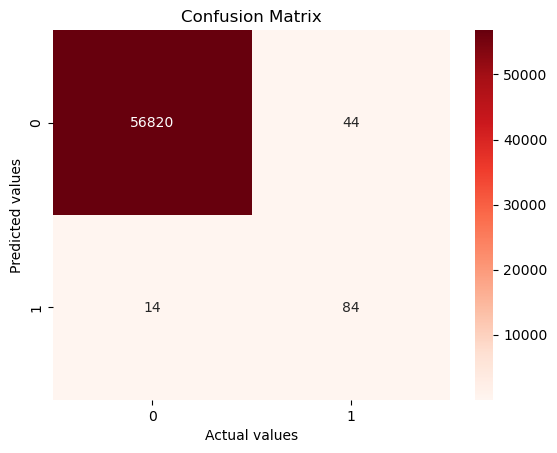

In [19]:
cr = classification_report(y_test,y_pred)
cm = confusion_matrix(y_test,y_pred)
sns.heatmap(cm, annot = True,fmt = "d",cmap = "Reds")
plt.title("Confusion Matrix")
plt.xlabel("Actual values")
plt.ylabel("Predicted values")
plt.savefig("Credit Card Fraud Model Confusion Matrix")

In [21]:
print(cr)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.66      0.86      0.74        98

    accuracy                           1.00     56962
   macro avg       0.83      0.93      0.87     56962
weighted avg       1.00      1.00      1.00     56962



In [35]:
fpr,tpr,_ = roc_curve(y_test,y_probs)

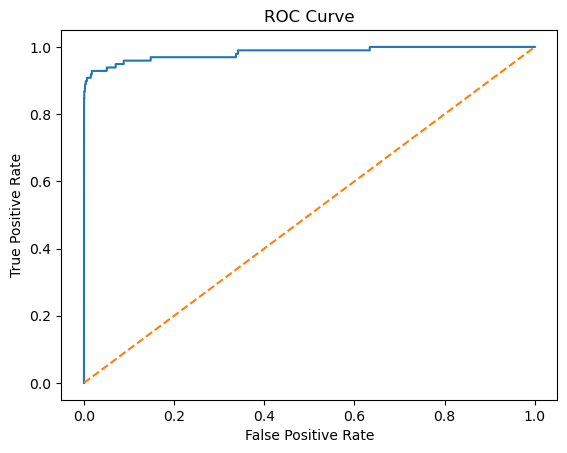

In [36]:
plt.plot(fpr,tpr,label = f"AUC = {roc_auc :.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.savefig("Credit Card Fraud Model ROC Curve")

In [37]:
X_train.columns

Index(['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11',
       'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21',
       'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount'],
      dtype='object')

In [38]:
df["Amount"]

0         149.62
1           2.69
2         378.66
3         123.50
4          69.99
           ...  
284802      0.77
284803     24.79
284804     67.88
284805     10.00
284806    217.00
Name: Amount, Length: 284807, dtype: float64

## Model Saving

In [39]:
pickle.dump(xgb, open("fraud_model.pkl","wb"))
pickle.dump(scaler, open("scaler.pkl","wb"))